# Quick Start Guide (Google Colab) - v2 (ResNet50 + Improved ResNet34)

## Before You Begin:

### Step 1: Get Kaggle API Credentials
1. Go to [Kaggle.com](https://www.kaggle.com/) and sign in
2. Click on your profile picture **Account**
3. Scroll to **API** section -> Click **Create New API Token**
4. Open the downloaded `kaggle.json` file and note:
   - Your **Kaggle Username**
   - Your **Kaggle API Key**

### Step 2: Enable GPU in Colab
- Runtime -> Change runtime type -> **T4 GPU** -> Save

### Step 3: Run This Notebook
1. **Run all cells** (Runtime -> Run all) OR run cells sequentially
2. **Enter your Kaggle credentials** when prompted
3. Wait ~90 minutes for training to complete
4. **Download results** automatically saved at the end

---

## What This Notebook Does (v2 Improvements):

- Downloads FER-2013 dataset from Kaggle
- Trains **6 new configurations**: ResNet50 (x3) + improved ResNet34 (x3)
- **3-phase progressive unfreezing** (fc -> layer4+fc -> layer3+layer4+fc)
- **Label smoothing** (0.1) + **Dropout** (0.3-0.5) for better regularisation
- **LR warmup** (3 epochs) + corrected CosineAnnealing T_max
- **Gradient clipping** (max_norm=1.0) for training stability
- **MixUp augmentation** on config 6 for extra regularisation
- **Heavy augmentation** tested systematically across all configs
- Generates identical analysis/visualization sections as v1
- Automatically ranks models and recommends top 2
- Downloads all results to your computer

---

**Expected Runtime:** ~80-100 minutes on T4 GPU

**Previous Best (v1):** Test Acc = 62.6% | **Target (v2):** 67-70%

**Let's begin!**


# ResNet50 / ResNet34-v2 Hyperparameter Tuning & Analysis
## Facial Emotion Recognition (FER-2013)
### Google Colab Ready - Version 2

This notebook implements and compares **6 new configurations** targeting **>67% test accuracy**:
- **ResNet50** (new - bottleneck architecture, more capacity)
- **Improved ResNet34** (3-phase fine-tuning, dropout, label smoothing)
- Learning rates: 3e-4, 1e-4
- Optimizers: Adam, AdamW
- Augmentation: medium, heavy (all configs include heavy aug variant)
- Batch sizes: 32 and 64
- Label smoothing (0.1), Dropout (0.3-0.5), MixUp (config 6)

**Architecture Question Answered:** ResNet34 best = 62.6% - upgrading to ResNet50 is warranted
(literature shows +2-4% on FER-2013; ResNet101+ has diminishing returns on 48x48px images)

**Goal**: Beat v1 best test accuracy of **62.58%**

**Runtime:** ~90 minutes on Colab T4 GPU

---

### Setup Instructions:

1. **Enable GPU:** Runtime -> Change runtime type -> T4 GPU
2. **Get Kaggle API Credentials:**
   - Go to Kaggle Account -> Create New API Token
   - Enter when prompted
3. **Run all cells** sequentially


## 1. Colab Environment Setup

In [1]:
!ls /kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models

resnet18_combo01_lr5e-5_bs32_aug_light_opt_adam_sched_step_acc0.6300.pth
resnet18_combo02_lr5e-5_bs32_aug_light_opt_adam_sched_cosine_acc0.6361.pth
resnet18_combo03_lr5e-5_bs32_aug_light_opt_adam_sched_plateau_acc0.6344.pth
resnet18_combo04_lr5e-5_bs32_aug_light_opt_adamw_sched_step_acc0.6364.pth
resnet18_combo05_lr5e-5_bs32_aug_light_opt_adamw_sched_cosine_acc0.6255.pth
resnet18_combo06_lr5e-5_bs32_aug_light_opt_adamw_sched_plateau_acc0.6241.pth
resnet18_combo07_lr5e-5_bs32_aug_light_opt_sgd_sched_step_acc0.4971.pth
resnet18_combo08_lr5e-5_bs32_aug_light_opt_sgd_sched_cosine_acc0.5024.pth
resnet18_combo09_lr5e-5_bs32_aug_light_opt_sgd_sched_plateau_acc0.5375.pth
resnet18_combo10_lr5e-5_bs32_aug_medium_opt_adam_sched_step_acc0.6353.pth
resnet18_combo11_lr5e-5_bs32_aug_medium_opt_adam_sched_cosine_acc0.6406.pth
resnet18_combo12_lr5e-5_bs32_aug_medium_opt_adam_sched_plateau_acc0.6381.pth
resnet18_combo13_lr5e-5_bs32_aug_medium_opt_adamw_sched_step_acc0.6386.pth
resnet18_combo14_lr5e-5_bs

In [2]:
!ls -a /kaggle/input/facial-expression-recognition

.  ..  FER_data.csv


In [3]:
# ====== KAGGLE/LOCAL SETUP ======
import os, sys, shutil
from pathlib import Path

# Check if running on Kaggle
is_kaggle = os.path.exists('/kaggle')
print(f"Running on Kaggle: {is_kaggle}")
print(f"Python version: {sys.version.split()[0]}")

if is_kaggle:
    DATASET_PATH = Path("/kaggle/input/facial-expression-recognition/FER_data.csv")
    SAVE_DIR = Path("/kaggle/working/saved_models")

    # ✅ Correct path to previously saved models
    PREV_MODELS_DIR = Path(
        "/kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models"
    )

else:
    PROJECT_ROOT = Path.cwd().parents[1]
    DATASET_PATH = PROJECT_ROOT / "Datasets" / "FER_data.csv"
    SAVE_DIR = PROJECT_ROOT / "Models" / "Saved_Models"
    PREV_MODELS_DIR = None

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- COPY PREVIOUS MODELS INTO WORKING ----------
if is_kaggle and PREV_MODELS_DIR.exists():
    print("Copying previous saved models into working directory...")
    copied = 0
    for file in PREV_MODELS_DIR.glob("*.pth"):
        dest = SAVE_DIR / file.name
        if not dest.exists():
            shutil.copy(file, dest)
            copied += 1
    print(f"✓ {copied} models copied into: {SAVE_DIR}")
else:
    print("No previous saved models found.")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

print(f"✓ Dataset found: {DATASET_PATH}")
print(f"✓ Models will be saved to: {SAVE_DIR}")

Running on Kaggle: True
Python version: 3.12.12
Copying previous saved models into working directory...
✓ 28 models copied into: /kaggle/working/saved_models
✓ Dataset found: /kaggle/input/facial-expression-recognition/FER_data.csv
✓ Models will be saved to: /kaggle/working/saved_models


In [17]:
MODELS_DIR=SAVE_DIR

## 2. Path Configuration

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter, defaultdict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support
)
import json
import time

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("System Information")
print("="*60)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Memory:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
else:
    print("WARNING: GPU not available! Training will be very slow.")
    print("   Please enable GPU: Runtime -> Change runtime type -> T4 GPU")
print("="*60)


System Information
Torch: 2.8.0+cu126
CUDA: 12.6
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.637086208 GB


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FER_LABELS = {0:"angry",1:"disgust",2:"fear",3:"happy",4:"sad",5:"surprise",6:"neutral"}
class_names = [FER_LABELS[i] for i in range(7)]


Using device: cuda


## 3. Load and Explore Dataset

In [6]:
data = pd.read_csv(DATASET_PATH)
data.columns = data.columns.str.strip()
print(data.info())
print("\nEmotion distribution:")
print(data['emotion'].value_counts().sort_index())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   Usage    35887 non-null  object
 2   pixels   35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB
None

Emotion distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


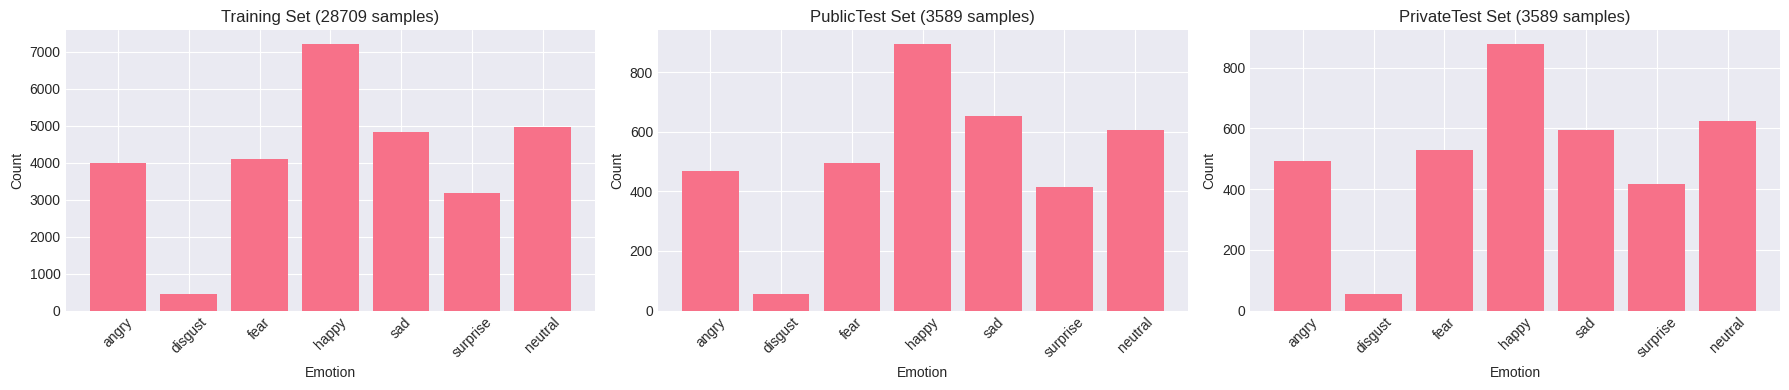

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, split in enumerate(["Training", "PublicTest", "PrivateTest"]):
    split_data = data[data["Usage"] == split]
    emotion_counts = split_data['emotion'].value_counts().sort_index()
    axes[idx].bar([class_names[i] for i in emotion_counts.index], emotion_counts.values)
    axes[idx].set_title(f"{split} Set ({len(split_data)} samples)")
    axes[idx].set_xlabel("Emotion")
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


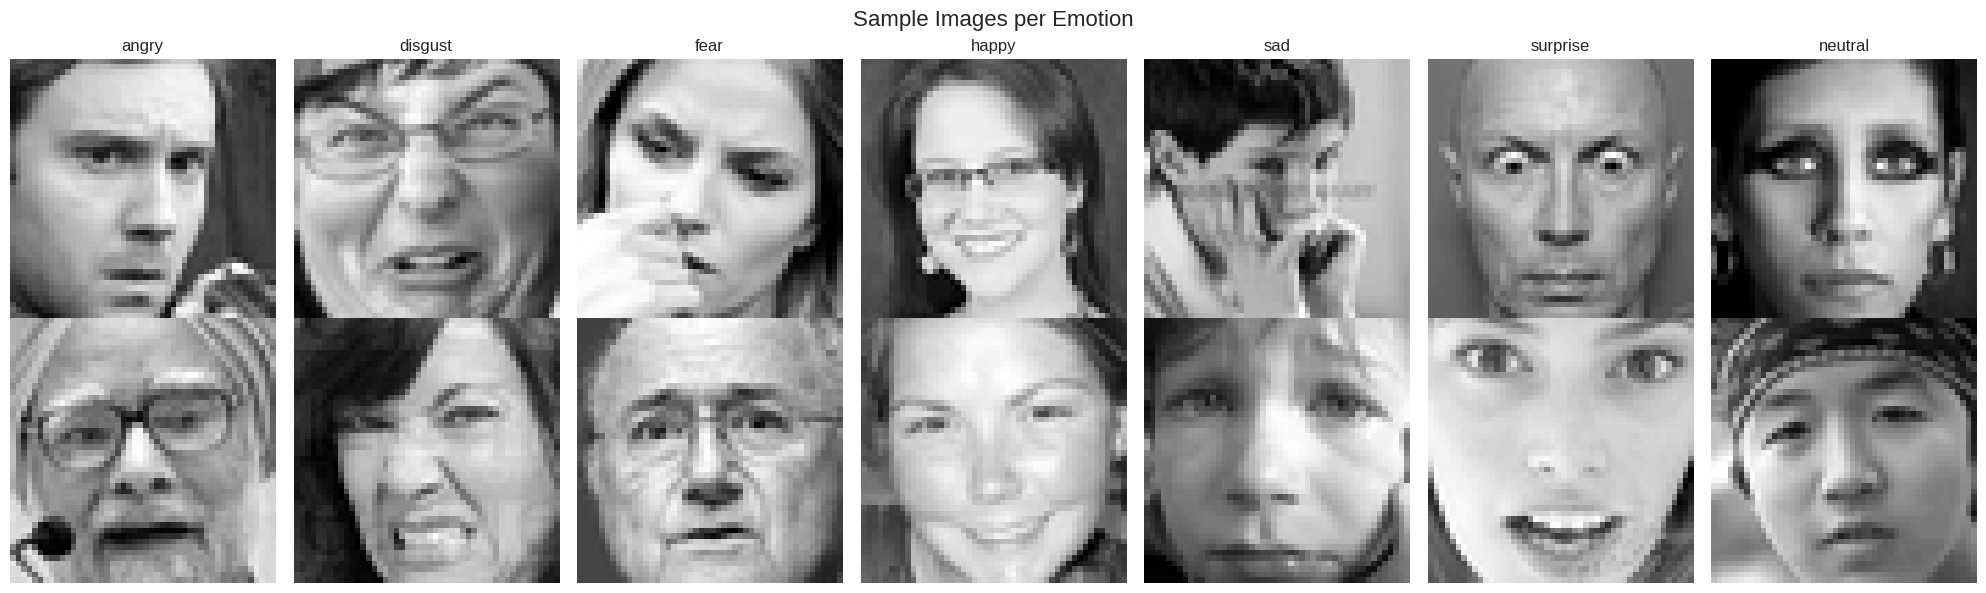

In [8]:
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle("Sample Images per Emotion", fontsize=16)

for emotion_id in range(7):
    emotion_samples = data[data['emotion'] == emotion_id].head(2)
    for row_idx, (_, sample) in enumerate(emotion_samples.iterrows()):
        pixels = np.array(sample['pixels'].split(), dtype=np.uint8)
        image = pixels.reshape(48, 48)
        axes[row_idx, emotion_id].imshow(image, cmap='gray')
        axes[row_idx, emotion_id].axis('off')
        if row_idx == 0:
            axes[row_idx, emotion_id].set_title(class_names[emotion_id])

plt.tight_layout()
plt.show()


## 4. Dataset Class & Augmentation Strategies

In [9]:
class FERDataset(Dataset):
    def __init__(self, dataframe, split, transform=None):
        self.data = dataframe[dataframe["Usage"] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        label = int(row["emotion"])
        pixels = np.array(row["pixels"].split(), dtype=np.uint8)
        image = pixels.reshape(48, 48)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label


def get_augmentation(aug_level="medium"):
    base_transform = [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
    ]

    if aug_level == "light":
        aug_transforms = [
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    elif aug_level == "medium":
        aug_transforms = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        ]
    elif aug_level == "heavy":
        # v2: more comprehensive heavy augmentation - systematically applied to all configs
        aug_transforms = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
            transforms.RandomGrayscale(p=0.05),           # v2 addition
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # v2 addition
        ]
    else:
        aug_transforms = []

    final_transforms = [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]

    return transforms.Compose(base_transform + aug_transforms + final_transforms)


def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# Test transform (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Augmentation strategies defined: light, medium, heavy (v2-enhanced)")
print("MixUp augmentation helper functions defined")


Augmentation strategies defined: light, medium, heavy (v2-enhanced)
MixUp augmentation helper functions defined


### v2 Augmentation Strategy Improvements

**Changes from v1:**
- **Heavy augmentation** is now systematically applied across **all 6 configs** (not just 1/5 as in v1)
- v1 only used heavy aug in 1 of 5 models -> severe under-exploration
- **New additions to heavy level:** GaussianBlur + optional RandomGrayscale
- **MixUp** added for config 6 (ResNet50 + medium aug) - interpolates between training samples

**Key Point:** combo01 (v1) with heavy aug had the *best generalization gap* (4%) despite lower raw accuracy.
v2 exploits this insight by using heavy aug + dropout + label smoothing together.


## 5. Model Configurations (v2 - 6 New Configs)

Based on the v1 analysis:
- **ResNet34 best test: 62.6%** - FER-2013 SOTA ~73-75% with deeper models
- ResNet50 expected +2-4% over ResNet34 on this task
- 3-phase progressive unfreezing to leverage more backbone layers
- Label smoothing + dropout to combat the 10-19% train-val gaps seen in v1


In [10]:
# v2 Model configurations - 6 new combos targeting >67% test accuracy
MODEL_CONFIGS = [
    # Config 1: ResNet50 | AdamW | heavy | bs64
    {
        "name": "resnet50_c1_lr3e-04_bs64_aug_heavy_opt_adamw_drop0.3_ls0.1",
        "arch": "resnet50",
        "lr": 0.0003,
        "batch_size": 64,
        "augmentation": "heavy",
        "optimizer": "adamw",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.3,
        "label_smoothing": 0.1,
        "use_mixup": False,
        "weight_decay": 0.01,
    },
    # Config 2: ResNet50 | AdamW | medium | bs64
    {
        "name": "resnet50_c2_lr1e-04_bs64_aug_medium_opt_adamw_drop0.3_ls0.1",
        "arch": "resnet50",
        "lr": 0.0001,
        "batch_size": 64,
        "augmentation": "medium",
        "optimizer": "adamw",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.3,
        "label_smoothing": 0.1,
        "use_mixup": False,
        "weight_decay": 0.01,
    },
    # Config 3: ResNet50 | Adam | heavy | bs32
    {
        "name": "resnet50_c3_lr3e-04_bs32_aug_heavy_opt_adam_drop0.5_ls0.1",
        "arch": "resnet50",
        "lr": 0.0003,
        "batch_size": 32,
        "augmentation": "heavy",
        "optimizer": "adam",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.5,
        "label_smoothing": 0.1,
        "use_mixup": False,
        "weight_decay": 0.0,
    },
    # Config 4: ResNet34 | Adam | heavy | bs64  (v1 best re-run with 3-phase)
    {
        "name": "resnet34_c4_lr3e-04_bs64_aug_heavy_opt_adam_drop0.3_ls0.1",
        "arch": "resnet34",
        "lr": 0.0003,
        "batch_size": 64,
        "augmentation": "heavy",
        "optimizer": "adam",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.3,
        "label_smoothing": 0.1,
        "use_mixup": False,
        "weight_decay": 0.0,
    },
    # Config 5: ResNet34 | AdamW | heavy | bs32
    {
        "name": "resnet34_c5_lr1e-04_bs32_aug_heavy_opt_adamw_drop0.5_ls0.1",
        "arch": "resnet34",
        "lr": 0.0001,
        "batch_size": 32,
        "augmentation": "heavy",
        "optimizer": "adamw",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.5,
        "label_smoothing": 0.1,
        "use_mixup": False,
        "weight_decay": 0.01,
    },
    # Config 6: ResNet50 | AdamW | medium | bs32 + MixUp
    {
        "name": "resnet50_c6_lr1e-04_bs32_aug_medium_opt_adamw_drop0.3_ls0.1_mixup",
        "arch": "resnet50",
        "lr": 0.0001,
        "batch_size": 32,
        "augmentation": "medium",
        "optimizer": "adamw",
        "scheduler": "cosine",
        "scheduler_params": {"T_max": 30, "eta_min": 1e-6},
        "dropout": 0.3,
        "label_smoothing": 0.1,
        "use_mixup": True,
        "weight_decay": 0.01,
    },
]

print(f"Configured {len(MODEL_CONFIGS)} v2 model variants")
print("\nSummary:")
for i, c in enumerate(MODEL_CONFIGS, 1):
    mixup_tag = " + MixUp" if c["use_mixup"] else ""
    print(f"  Config {i}: {c['arch']:8s} | LR={c['lr']:.0e} | BS={c['batch_size']:2d} | "
          f"aug={c['augmentation']:6s} | {c['optimizer'].upper():5s} | "
          f"dropout={c['dropout']} | label_smooth={c['label_smoothing']}{mixup_tag}")


Configured 6 v2 model variants

Summary:
  Config 1: resnet50 | LR=3e-04 | BS=64 | aug=heavy  | ADAMW | dropout=0.3 | label_smooth=0.1
  Config 2: resnet50 | LR=1e-04 | BS=64 | aug=medium | ADAMW | dropout=0.3 | label_smooth=0.1
  Config 3: resnet50 | LR=3e-04 | BS=32 | aug=heavy  | ADAM  | dropout=0.5 | label_smooth=0.1
  Config 4: resnet34 | LR=3e-04 | BS=64 | aug=heavy  | ADAM  | dropout=0.3 | label_smooth=0.1
  Config 5: resnet34 | LR=1e-04 | BS=32 | aug=heavy  | ADAMW | dropout=0.5 | label_smooth=0.1
  Config 6: resnet50 | LR=1e-04 | BS=32 | aug=medium | ADAMW | dropout=0.3 | label_smooth=0.1 + MixUp


## 6. Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device,
                    phase_name="", use_mixup=False, clip_grad=1.0):
    # v2: gradient clipping + MixUp support
    model.train()
    total_loss = 0
    correct = 0
    total_samples = 0

    pbar = tqdm(loader, desc=f"Training {phase_name}", leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        if use_mixup:
            images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.4)
            optimizer.zero_grad()
            outputs = model(images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping (v2 addition)
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total_samples += images.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct / total_samples:.4f}"
        })

    return total_loss / total_samples, correct / total_samples


def evaluate(model, loader, criterion, device, return_predictions=False):
    # Evaluate model - unchanged structure from v1
    model.eval()
    total_loss, correct, total_samples = 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_samples += images.size(0)
            if return_predictions:
                all_preds.append(preds.cpu().numpy())
                all_targets.append(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples

    if return_predictions:
        return avg_loss, accuracy, np.concatenate(all_preds), np.concatenate(all_targets)
    return avg_loss, accuracy


print("Training and evaluation functions defined (v2: grad clipping, MixUp support)")


Training and evaluation functions defined (v2: grad clipping, MixUp support)


In [12]:
def build_model(config, device):
    # Build ResNet34 or ResNet50 with optional dropout before fc (v2)
    arch = config.get("arch", "resnet34")
    dropout_p = config.get("dropout", 0.0)

    if arch == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
    else:  # resnet34
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features

    # Replace classifier with Dropout + Linear (v2)
    if dropout_p > 0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, 7)
        )
    else:
        model.fc = nn.Linear(in_features, 7)

    return model.to(device)


print("Model builder defined (supports ResNet34 / ResNet50 with configurable dropout)")


Model builder defined (supports ResNet34 / ResNet50 with configurable dropout)


In [13]:
def get_linear_warmup_scheduler(optimizer, warmup_epochs, base_scheduler):
    # Combines linear warmup with a base scheduler (v2 addition)
    from torch.optim.lr_scheduler import LambdaLR, SequentialLR

    warmup_scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: float(epoch + 1) / float(warmup_epochs)
    )
    return SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, base_scheduler],
        milestones=[warmup_epochs]
    )


print("LR warmup scheduler defined (3-epoch linear warmup -> CosineAnnealing)")


LR warmup scheduler defined (3-epoch linear warmup -> CosineAnnealing)


In [14]:
def train_model_three_phase(config, train_loader, val_loader, test_loader,
                            class_weights, device):
    # v2: 3-phase progressive unfreezing training.
    # Phase 1 ( 5 ep): fc only                    - learn task head
    # Phase 2 (10 ep): layer4 + fc                - fine-tune high-level features
    # Phase 3 (15 ep): layer3 + layer4 + fc       - mid-level emotion features
    #
    # Improvements over v1:
    # - Label smoothing in loss
    # - LR warmup (3 epochs) in Phase 2 and 3
    # - Gradient clipping (max_norm=1.0)
    # - CosineAnnealing T_max matches actual phase length
    # - MixUp support (if config use_mixup is True)

    print(f"\n{'='*80}")
    print(f"Training (v2 3-phase): {config['name']}")
    print(f"{'='*80}")
    print(f"Arch={config['arch']:8s}  LR={config['lr']:.1e}  BS={config['batch_size']}"
          f"  Aug={config['augmentation']}  Opt={config['optimizer'].upper()}"
          f"  Dropout={config['dropout']}  LabelSmooth={config['label_smoothing']}"
          f"  MixUp={config['use_mixup']}")

    model = build_model(config, device)

    # Label-smoothed loss for training, plain loss for evaluation
    criterion_train = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config.get("label_smoothing", 0.0)
    )
    criterion_eval = nn.CrossEntropyLoss(weight=class_weights)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "test_acc":   [], "lr":        [],
        "epoch_time": [], "phase":     []
    }

    best_val_acc = 0.0
    best_model_state = None
    use_mixup = config.get("use_mixup", False)

    def _make_optimizer(params, lr_override=None):
        lr = lr_override or config['lr']
        wd = config.get("weight_decay", 0.0)
        if config['optimizer'] == 'adamw':
            return torch.optim.AdamW(params, lr=lr, weight_decay=wd)
        else:
            return torch.optim.Adam(params, lr=lr)

    def _run_epoch(phase_label, phase_num, optimizer, scheduler=None):
        nonlocal best_val_acc, best_model_state
        start_time = time.time()

        tl, ta = train_one_epoch(model, train_loader, criterion_train, optimizer,
                                 device, phase_label, use_mixup=use_mixup, clip_grad=1.0)
        vl, va = evaluate(model, val_loader, criterion_eval, device)
        _, ta_test = evaluate(model, test_loader, criterion_eval, device)

        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["test_acc"].append(ta_test)
        history["lr"].append(optimizer.param_groups[0]['lr'])
        history["epoch_time"].append(epoch_time)
        history["phase"].append(phase_num)

        if va > best_val_acc:
            best_val_acc = va
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            return True
        return False

    # PHASE 1: fc only
    print("\n" + "="*50)
    print("PHASE 1 (5 ep): Training classifier head only (frozen backbone)")
    print("="*50)
    for name, p in model.named_parameters():
        p.requires_grad = "fc" in name

    opt1   = _make_optimizer(filter(lambda p: p.requires_grad, model.parameters()))
    sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=5, eta_min=1e-6)

    for epoch in range(5):
        improved = _run_epoch(f"P1-E{epoch+1}", 1, opt1, sched1)
        h = history
        print(f"[P1][E{epoch+1:02d}/05] "
              f"TrLoss={h['train_loss'][-1]:.4f} TrAcc={h['train_acc'][-1]:.4f} | "
              f"ValLoss={h['val_loss'][-1]:.4f} ValAcc={h['val_acc'][-1]:.4f} | "
              f"TestAcc={h['test_acc'][-1]:.4f} | {h['epoch_time'][-1]:.1f}s"
              + (" *" if improved else ""))

    # PHASE 2: layer4 + fc
    print("\n" + "="*50)
    print("PHASE 2 (10 ep): Fine-tuning layer4 + fc (3-ep LR warmup)")
    print("="*50)
    for p in model.layer4.parameters():
        p.requires_grad = True

    opt2   = _make_optimizer(filter(lambda p: p.requires_grad, model.parameters()),
                             lr_override=config['lr'] * 0.1)
    cosine2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=config['scheduler_params']['T_max'], eta_min=1e-6)
    sched2 = get_linear_warmup_scheduler(opt2, warmup_epochs=3, base_scheduler=cosine2)

    patience_counter = 0
    patience = 4
    for epoch in range(10):
        improved = _run_epoch(f"P2-E{epoch+1}", 2, opt2, sched2)
        h = history
        print(f"[P2][E{epoch+1:02d}/10] "
              f"TrLoss={h['train_loss'][-1]:.4f} TrAcc={h['train_acc'][-1]:.4f} | "
              f"ValLoss={h['val_loss'][-1]:.4f} ValAcc={h['val_acc'][-1]:.4f} | "
              f"TestAcc={h['test_acc'][-1]:.4f} | LR={h['lr'][-1]:.2e} | {h['epoch_time'][-1]:.1f}s"
              + (" *" if improved else ""))
        if not improved:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping in Phase 2 (patience={patience})")
                break
        else:
            patience_counter = 0

    # PHASE 3: layer3 + layer4 + fc
    print("\n" + "="*50)
    print("PHASE 3 (15 ep): Fine-tuning layer3 + layer4 + fc (3-ep LR warmup)")
    print("="*50)
    for p in model.layer3.parameters():
        p.requires_grad = True

    opt3 = _make_optimizer(filter(lambda p: p.requires_grad, model.parameters()),
                           lr_override=config['lr'] * 0.01)
    cosine3 = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt3, T_max=config['scheduler_params']['T_max'], eta_min=1e-6)
    sched3 = get_linear_warmup_scheduler(opt3, warmup_epochs=3, base_scheduler=cosine3)

    patience_counter = 0
    for epoch in range(15):
        improved = _run_epoch(f"P3-E{epoch+1}", 3, opt3, sched3)
        h = history
        print(f"[P3][E{epoch+1:02d}/15] "
              f"TrLoss={h['train_loss'][-1]:.4f} TrAcc={h['train_acc'][-1]:.4f} | "
              f"ValLoss={h['val_loss'][-1]:.4f} ValAcc={h['val_acc'][-1]:.4f} | "
              f"TestAcc={h['test_acc'][-1]:.4f} | LR={h['lr'][-1]:.2e} | {h['epoch_time'][-1]:.1f}s"
              + (" *" if improved else ""))
        if not improved:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping in Phase 3 (patience={patience})")
                break
        else:
            patience_counter = 0

    # Load best & final evaluation
    model.load_state_dict(best_model_state)

    print("\n" + "="*50)
    print("Final Evaluation on Best Model Checkpoint")
    print("="*50)

    train_loss, train_acc, train_pred, train_true = evaluate(
        model, train_loader, criterion_eval, device, return_predictions=True)
    val_loss,   val_acc,   val_pred,   val_true   = evaluate(
        model, val_loader,   criterion_eval, device, return_predictions=True)
    test_loss,  test_acc,  test_pred,  test_true  = evaluate(
        model, test_loader,  criterion_eval, device, return_predictions=True)

    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f},   Acc: {val_acc:.4f}")
    print(f"Test  - Loss: {test_loss:.4f},  Acc: {test_acc:.4f}")

    results = {
        "config": config,
        "history": history,
        "final_metrics": {
            "train_acc": train_acc, "train_loss": train_loss,
            "train_f1_macro":    f1_score(train_true, train_pred, average='macro'),
            "train_f1_weighted": f1_score(train_true, train_pred, average='weighted'),
            "val_acc":   val_acc,   "val_loss":   val_loss,
            "val_f1_macro":      f1_score(val_true,   val_pred,   average='macro'),
            "val_f1_weighted":   f1_score(val_true,   val_pred,   average='weighted'),
            "test_acc":  test_acc,  "test_loss":  test_loss,
            "test_f1_macro":     f1_score(test_true,  test_pred,  average='macro'),
            "test_f1_weighted":  f1_score(test_true,  test_pred,  average='weighted'),
        },
        "predictions": {
            "train": (train_pred, train_true),
            "val":   (val_pred,   val_true),
            "test":  (test_pred,  test_true)
        },
        "model_state": best_model_state
    }
    return results

print("3-phase training function defined (v2)")


3-phase training function defined (v2)


## 7. Train All Model Configurations

Estimated time on Colab T4 GPU: ~80-100 minutes for all 6 models

**v2 Phase structure (per model):**
Phase 1: 5 ep (fc only) -> Phase 2: 10 ep (layer4+fc, warmup) -> Phase 3: 15 ep (layer3+layer4+fc, warmup)
Total: up to **30 epochs** vs 20 in v1 (with early stopping per phase).


In [15]:
train_labels = data[data["Usage"] == "Training"]["emotion"].values
counts = Counter(train_labels)
class_weights = [1.0 / counts[i] for i in range(7)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights.cpu().numpy())


Class weights: [0.00025031 0.00229358 0.00024408 0.0001386  0.00020704 0.00031536
 0.00020141]


In [ ]:
all_results = []

for config in MODEL_CONFIGS:
    print(f"\n{'='*80}")
    print(f"Preparing Model: {config['name']}")
    print(f"   Architecture: {config['arch'].upper()}  Augmentation: {config['augmentation'].upper()}")
    print(f"{'='*80}")

    train_transform = get_augmentation(config['augmentation'])

    train_dataset = FERDataset(data, split="Training",    transform=train_transform)
    val_dataset   = FERDataset(data, split="PublicTest",  transform=test_transform)
    test_dataset  = FERDataset(data, split="PrivateTest", transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=config['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=config['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"Starting 3-phase training with {config['augmentation']} augmentation...\n")
    results = train_model_three_phase(
        config, train_loader, val_loader, test_loader, class_weights, device
    )
    all_results.append(results)

    model_save_path = MODELS_DIR / f"{config['name']}.pth"
    torch.save({
        "model_state_dict": results['model_state'],
        "config": config,
        "final_metrics": results['final_metrics']
    }, model_save_path)
    print(f"\nModel saved: {model_save_path}\n")

print("\n" + "="*80)
print("ALL 6 v2 MODELS TRAINED SUCCESSFULLY!")
print("="*80)
print("\nNow proceeding to comprehensive analysis...")



Preparing Model: resnet50_c1_lr3e-04_bs64_aug_heavy_opt_adamw_drop0.3_ls0.1
   Architecture: RESNET50  Augmentation: HEAVY
Starting 3-phase training with heavy augmentation...


Training (v2 3-phase): resnet50_c1_lr3e-04_bs64_aug_heavy_opt_adamw_drop0.3_ls0.1
Arch=resnet50  LR=3.0e-04  BS=64  Aug=heavy  Opt=ADAMW  Dropout=0.3  LabelSmooth=0.1  MixUp=False

PHASE 1 (5 ep): Training classifier head only (frozen backbone)


[P1][E01/05] TrLoss=2.0828 TrAcc=0.1631 | ValLoss=1.9538 ValAcc=0.0922 | TestAcc=0.0906 | 154.6s *


[P1][E02/05] TrLoss=2.0090 TrAcc=0.2290 | ValLoss=1.7984 ValAcc=0.1279 | TestAcc=0.1307 | 153.6s *


[P1][E03/05] TrLoss=1.9943 TrAcc=0.2446 | ValLoss=1.6893 ValAcc=0.3112 | TestAcc=0.3132 | 153.5s *


[P1][E04/05] TrLoss=1.9840 TrAcc=0.2486 | ValLoss=1.7241 ValAcc=0.2079 | TestAcc=0.2079 | 152.7s


...

[P2][E02/10] TrLoss=1.9447 TrAcc=0.2474 | ValLoss=1.5350 ValAcc=0.3993 | TestAcc=0.3906 | LR=1.00e-05 | 152.7s *


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[P2][E03/10] TrLoss=1.8967 TrAcc=0.2782 | ValLoss=1.4357 ValAcc=0.4812 | TestAcc=0.4865 | LR=1.00e-05 | 152.8s *


[P2][E04/10] TrLoss=1.8496 TrAcc=0.3039 | ValLoss=1.3794 ValAcc=0.4985 | TestAcc=0.5149 | LR=9.98e-06 | 153.1s *


Training P2-E5:  26%|██▌       | 229/898 [00:33<01:37,  6.85it/s, loss=1.8700, acc=0.3111]

## 8. Comprehensive Performance Analysis

Results from v2 training are analyzed below


### 8.1 Summary Table of All Models

In [ ]:
summary_data = []
for result in all_results:
    config  = result['config']
    metrics = result['final_metrics']
    summary_data.append({
        "Model":        config['name'].split('_')[1],
        "Arch":         config['arch'],
        "LR":           config['lr'],
        "BS":           config['batch_size'],
        "Augmentation": config['augmentation'],
        "Optimizer":    config['optimizer'].upper(),
        "Dropout":      config['dropout'],
        "MixUp":        config['use_mixup'],
        "Train Acc":    f"{metrics['train_acc']:.4f}",
        "Val Acc":      f"{metrics['val_acc']:.4f}",
        "Test Acc":     f"{metrics['test_acc']:.4f}",
        "Train F1":     f"{metrics['train_f1_macro']:.4f}",
        "Val F1":       f"{metrics['val_f1_macro']:.4f}",
        "Test F1":      f"{metrics['test_f1_macro']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*120)
print("MODEL PERFORMANCE SUMMARY  (v2)")
print("="*120)
print(summary_df.to_string(index=False))
print("="*120)

v2_best = max(float(r['Test Acc']) for r in summary_data)
print(f"\nv1 Best Test Acc: 0.6258  -->  v2 Best Test Acc: {v2_best:.4f}")


### 8.2 Training Curves - Loss & Accuracy

In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Training Curves - All v2 Models", fontsize=18, fontweight='bold')

for idx, result in enumerate(all_results):
    history = result['history']
    config  = result['config']
    label   = f"{config['name'].split('_')[1]} ({config['arch']}/{config['augmentation']}/{config['optimizer']})"
    epochs  = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], label=label, color=colors[idx], linewidth=2)
    axes[0, 1].plot(epochs, history['val_loss'],   label=label, color=colors[idx], linewidth=2)
    axes[0, 2].plot(epochs, history['train_acc'],  label=label, color=colors[idx], linewidth=2)
    axes[1, 0].plot(epochs, history['val_acc'],    label=label, color=colors[idx], linewidth=2)
    axes[1, 1].plot(epochs, history['test_acc'],   label=label, color=colors[idx], linewidth=2)
    axes[1, 2].plot(epochs, history['lr'],         label=label, color=colors[idx], linewidth=2)

titles  = ['Training Loss','Validation Loss','Training Accuracy',
           'Validation Accuracy','Test Accuracy','Learning Rate']
ylabels = ['Loss','Loss','Accuracy','Accuracy','Accuracy','LR']

for ax, title, ylabel in zip(axes.flatten(), titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
    if 'LR' in title:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()


### 8.3 Overfitting/Underfitting Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Overfitting Analysis: Train-Val Gap (v2)", fontsize=16, fontweight='bold')

for idx, result in enumerate(all_results):
    history = result['history']
    config  = result['config']
    label   = f"{config['name'].split('_')[1]} ({config['arch']})"
    epochs  = range(1, len(history['train_loss']) + 1)

    loss_gap = np.array(history['train_loss']) - np.array(history['val_loss'])
    acc_gap  = np.array(history['train_acc'])  - np.array(history['val_acc'])
    axes[0].plot(epochs, loss_gap, label=label, color=colors[idx], linewidth=2)
    axes[1].plot(epochs, acc_gap,  label=label, color=colors[idx], linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Training Loss - Validation Loss','Training Accuracy - Validation Accuracy'],
    ['Loss Gap','Accuracy Gap']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- v2 target: Train-Val gap < 5% (v1 had up to 19% gap)")
print("- Label smoothing + dropout + heavy aug should reduce the gap")
print("- Phase-boundary spikes expected at epoch ~5 (P1->P2) and ~15 (P2->P3)")


### 8.4 Phase Transition Analysis

In [ ]:
for result in all_results:
    config  = result['config']
    history = result['history']
    metrics = result['final_metrics']

    print(f"\n{'='*80}")
    print(f"Model: {config['name']}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Detailed Analysis (v2): {config['name'].split('_')[1]}",
                 fontsize=14, fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)
    phases = history["phase"]
    p2_start = next((i for i, p in enumerate(phases) if p == 2), None)
    p3_start = next((i for i, p in enumerate(phases) if p == 3), None)

    def add_phase_lines(ax):
        if p2_start is not None:
            ax.axvline(x=p2_start, color='orange', linestyle='--', alpha=0.6,
                       label='Phase 2 Start (layer4 unfrozen)')
        if p3_start is not None:
            ax.axvline(x=p3_start, color='red', linestyle='--', alpha=0.6,
                       label='Phase 3 Start (layer3 unfrozen)')

    # Loss curves
    axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
    axes[0, 0].plot(epochs, history['val_loss'],   label='Val Loss',   linewidth=2, marker='s', markersize=3)
    add_phase_lines(axes[0, 0])
    axes[0, 0].set_title('Loss Curves', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

    # Accuracy curves
    axes[0, 1].plot(epochs, history['train_acc'], label='Train Acc', linewidth=2, marker='o', markersize=3)
    axes[0, 1].plot(epochs, history['val_acc'],   label='Val Acc',   linewidth=2, marker='s', markersize=3)
    axes[0, 1].plot(epochs, history['test_acc'],  label='Test Acc',  linewidth=2, marker='^', markersize=3)
    add_phase_lines(axes[0, 1])
    axes[0, 1].set_title('Accuracy Curves', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

    # Generalization gap
    train_val_gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[1, 0].plot(epochs, train_val_gap, linewidth=2, color='purple', marker='o', markersize=3)
    axes[1, 0].axhline(y=0,    color='black',  linestyle='--', alpha=0.5)
    axes[1, 0].axhline(y=0.05, color='orange', linestyle=':',  alpha=0.5, label='5% threshold')
    axes[1, 0].axhline(y=0.10, color='red',    linestyle=':',  alpha=0.5, label='10% threshold')
    add_phase_lines(axes[1, 0])
    axes[1, 0].set_title('Generalization Gap (Train Acc - Val Acc)', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy Gap')
    axes[1, 0].legend(fontsize=8); axes[1, 0].grid(True, alpha=0.3)

    # LR schedule
    axes[1, 1].plot(epochs, history['lr'], linewidth=2, color='green', marker='o', markersize=3)
    add_phase_lines(axes[1, 1])
    axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log'); axes[1, 1].legend(fontsize=8); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    final_gap = history['train_acc'][-1] - history['val_acc'][-1]
    print(f"Config: arch={config['arch']}  LR={config['lr']}  aug={config['augmentation']}"
          f"  opt={config['optimizer'].upper()}  dropout={config['dropout']}  mixup={config['use_mixup']}")
    print(f"Final Performance: Train={metrics['train_acc']:.4f}  Val={metrics['val_acc']:.4f}  Test={metrics['test_acc']:.4f}")
    gap_msg = "Overfitting (gap > 10%)" if final_gap > 0.1 else (
              "Moderate overfitting (5-10%)" if final_gap > 0.05 else
              "Good generalization (gap <= 5%)")
    print(f"Generalization Gap: {final_gap:.4f}  [{gap_msg}]")
    print(f"Training Time: {sum(history['epoch_time']):.1f}s  ({sum(history['epoch_time'])/60:.1f} min)")


## 9. Confusion Matrices & Classification Reports

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           title=title, ylabel='True Label', xlabel='Predicted Label')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_normalized.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}\n({cm_normalized[i, j]:.2%})",
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    return fig


In [ ]:
for result in all_results:
    config      = result['config']
    predictions = result['predictions']

    print("\n" + "="*80)
    print(f"Confusion Matrices (v2): {config['name']}")
    print("="*80)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Confusion Matrices - {config['name'].split('_')[1]} ({config['arch']})",
                 fontsize=14, fontweight='bold')

    for idx, (split_name, (y_pred, y_true)) in enumerate(
        [("Validation", predictions['val']), ("Test", predictions['test'])]
    ):
        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        im = axes[idx].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
        axes[idx].set_xticks(np.arange(len(class_names)))
        axes[idx].set_yticks(np.arange(len(class_names)))
        axes[idx].set_xticklabels(class_names)
        axes[idx].set_yticklabels(class_names)
        axes[idx].set_title(f"{split_name} Set", fontweight='bold')
        axes[idx].set_ylabel('True Label'); axes[idx].set_xlabel('Predicted Label')
        plt.setp(axes[idx].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        thresh = cm_normalized.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                axes[idx].text(j, i, f"{cm[i, j]}\n({cm_normalized[i, j]:.1%})",
                               ha="center", va="center",
                               color="white" if cm_normalized[i, j] > thresh else "black",
                               fontsize=9)
        plt.colorbar(im, ax=axes[idx])

    plt.tight_layout()
    plt.show()

    print(f"\nClassification Report - Validation Set:")
    print(classification_report(predictions['val'][1], predictions['val'][0],
                                target_names=class_names, digits=4))
    print(f"\nClassification Report - Test Set:")
    print(classification_report(predictions['test'][1], predictions['test'][0],
                                target_names=class_names, digits=4))


## 10. Per-Class Performance Analysis

In [ ]:
best_model_idx = np.argmax([r['final_metrics']['test_acc'] for r in all_results])
best_result    = all_results[best_model_idx]

print("\n" + "="*80)
print(f"Per-Class Analysis - Best v2 Model: {best_result['config']['name']}")
print("="*80)

y_pred_test, y_true_test = best_result['predictions']['test']
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_test, y_pred_test, labels=range(7)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Per-Class Performance - Best v2 Model", fontsize=14, fontweight='bold')

x = np.arange(len(class_names)); width = 0.6

for ax, values, title, ylabel, color in zip(
    axes.flatten(),
    [precision, recall, f1, support],
    ['Precision per Class','Recall per Class','F1-Score per Class','Sample Count per Class'],
    ['Precision','Recall','F1-Score','Number of Samples'],
    ['skyblue','lightcoral','lightgreen','plum']
):
    ax.bar(x, values, width, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        lbl = f'{int(v)}' if title == 'Sample Count per Class' else f'{v:.3f}'
        offset = 20 if title == 'Sample Count per Class' else 0.02
        ax.text(i, v + offset, lbl, ha='center', fontsize=9)
    if title != 'Sample Count per Class':
        ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()


## 11. Model Comparison Visualizations

In [ ]:
model_names = [f"{r['config']['name'].split('_')[1]}\n({r['config']['arch']})" for r in all_results]

train_accs = [r['final_metrics']['train_acc'] for r in all_results]
val_accs   = [r['final_metrics']['val_acc']   for r in all_results]
test_accs  = [r['final_metrics']['test_acc']  for r in all_results]
train_f1s  = [r['final_metrics']['train_f1_macro'] for r in all_results]
val_f1s    = [r['final_metrics']['val_f1_macro']   for r in all_results]
test_f1s   = [r['final_metrics']['test_f1_macro']  for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Model Comparison - All v2 Configurations", fontsize=16, fontweight='bold')

x = np.arange(len(model_names)); width = 0.25

for ax, (ta, va, ta2), title, ylabel, ylim in zip(
    axes,
    [(train_accs, val_accs, test_accs), (train_f1s, val_f1s, test_f1s)],
    ['Accuracy Comparison','F1-Score (Macro) Comparison'],
    ['Accuracy','F1-Score'],
    [[0.5, 1.0],[0.4, 1.0]]
):
    ax.bar(x - width, ta,  width, label='Train',      color='skyblue')
    ax.bar(x,          va,  width, label='Validation', color='orange')
    ax.bar(x + width,  ta2, width, label='Test',       color='green')
    ax.axhline(y=0.6258, color='red', linestyle='--', alpha=0.7, label='v1 best test (0.6258)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_xlabel('Model Configuration')
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(ylim)

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for idx, result in enumerate(all_results):
    val_acc  = result['final_metrics']['val_acc']
    test_acc = result['final_metrics']['test_acc']
    config   = result['config']
    label    = f"{config['name'].split('_')[1]} ({config['arch']}/{config['augmentation']})"

    ax.scatter(val_acc, test_acc, s=200, alpha=0.7, label=label, color=colors[idx])
    ax.annotate(config['name'].split('_')[1], (val_acc, test_acc), fontsize=10, ha='center')

# v1 best reference point
ax.scatter(0.6695, 0.6258, s=300, marker='*', color='red', zorder=5, label='v1 best')
ax.annotate('v1 best', (0.6695, 0.6258), fontsize=10, color='red', ha='center')

lims = [0.58, 0.75]
ax.plot(lims, lims, 'k--', alpha=0.3, zorder=0)
ax.set_xlabel('Validation Accuracy', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Validation vs Test Accuracy - v2 Models', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3); ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()


## 12. Final Summary & Recommendations

In [ ]:
best_model_idx = np.argmax([r['final_metrics']['test_acc'] for r in all_results])
best_result    = all_results[best_model_idx]
best_config    = best_result['config']
best_metrics   = best_result['final_metrics']

print("\n" + "="*80)
print("FINAL SUMMARY & RECOMMENDATIONS  (v2)")
print("="*80)

print("\nBEST v2 MODEL:")
print(f"  Name: {best_config['name']}")
print(f"  Architecture: {best_config['arch'].upper()}")
print(f"  LR={best_config['lr']}  BS={best_config['batch_size']}"
      f"  Aug={best_config['augmentation']}  Opt={best_config['optimizer'].upper()}"
      f"  Dropout={best_config['dropout']}  MixUp={best_config['use_mixup']}")

print(f"\n  Performance:")
print(f"    Train Acc: {best_metrics['train_acc']:.4f}  |  F1: {best_metrics['train_f1_macro']:.4f}")
print(f"    Val   Acc: {best_metrics['val_acc']:.4f}  |  F1: {best_metrics['val_f1_macro']:.4f}")
print(f"    Test  Acc: {best_metrics['test_acc']:.4f}  |  F1: {best_metrics['test_f1_macro']:.4f}")

v1_best = 0.6258
v2_best = best_metrics['test_acc']
print(f"\nImprovement over v1: {v2_best - v1_best:+.4f} ({(v2_best-v1_best)/v1_best*100:+.1f}%)")

aug_performance = defaultdict(list)
for result in all_results:
    aug_performance[result['config']['augmentation']].append(result['final_metrics']['test_acc'])

arch_performance = defaultdict(list)
for result in all_results:
    arch_performance[result['config']['arch']].append(result['final_metrics']['test_acc'])

print("\nKEY FINDINGS (v2):")
print("\n  1. Architecture Impact:")
for arch, accs in sorted(arch_performance.items()):
    print(f"     {arch.upper():8s}: Avg Test Acc = {np.mean(accs):.4f} (best = {max(accs):.4f})")

print("\n  2. Augmentation Strategy Impact (v2 - all get heavy or medium):")
for aug in ['medium', 'heavy']:
    if aug in aug_performance:
        print(f"     {aug.capitalize():6s}: Avg Test Acc = {np.mean(aug_performance[aug]):.4f}")

opt_performance = defaultdict(list)
for result in all_results:
    opt_performance[result['config']['optimizer']].append(result['final_metrics']['test_acc'])
print("\n  3. Optimizer Impact:")
for opt, accs in sorted(opt_performance.items()):
    print(f"     {opt.upper():5s}: Avg Test Acc = {np.mean(accs):.4f}")

print("\nRECOMMENDATIONS:")
print("  1. Use best v2 model for production deployment")
print("  2. If more improvement needed: try EfficientNet-B0/B2 or ViT-small")
print("  3. Curriculum learning: start with easy emotions, add harder ones")
print("  4. Most confused classes:")

y_pred_best, y_true_best = best_result['predictions']['test']
cm_best = confusion_matrix(y_true_best, y_pred_best)
cm_no_diag = cm_best.copy()
np.fill_diagonal(cm_no_diag, 0)
confused_pairs = [(i, j, cm_no_diag[i, j]) for i in range(7) for j in range(7) if i != j and cm_no_diag[i, j] > 0]
confused_pairs.sort(key=lambda x: x[2], reverse=True)
for i, j, count in confused_pairs[:5]:
    print(f"     - {class_names[i]} misclassified as {class_names[j]}: {int(count)} times")

print("\n" + "="*80)
print("v2 Analysis complete! All 6 models trained and evaluated.")
print("="*80)


---

### How to Select Your Best 2 Models (v2)

**Primary Criteria:**
1. **Highest Test Accuracy** - main metric
2. **Low Train-Val Gap** - v2 target < 5% (v1 had up to 19%)
3. **Val-Test agreement** - close gap = good generalisation
4. **High F1 (macro)** - balanced across all 7 emotions

**v2 Decision Framework:**
- **Model #1:** Highest test accuracy with gap < 10%
- **Model #2:** Best at reducing the train-val gap (most regularised)

Saved `.pth` files are in the `Saved_Models_v2/` directory.


## 13. Save Results Summary

In [ ]:
# Optional: Create a ZIP file of all models for easy download
import shutil
from pathlib import Path
if Path("/kaggle").exists():
    zip_path = "/kaggle/working/all_randomsearch_models"
    print("Creating ZIP archive of all models...")
    shutil.make_archive(zip_path, 'zip', SAVE_DIR)
    print(f"✓ ZIP created: {zip_path}.zip")
    print(f"  Size: {Path(f'{zip_path}.zip').stat().st_size / 1e6:.2f} MB")
    print("\nTo download:")
    print("1. Click 'Save Version' (top right)")
    print("2. Go to 'Output' tab")
    print("3. Download 'all_randomsearch_models.zip'")
else:
    print("Not running on Kaggle - skipping ZIP creation")

In [ ]:
import shutil
import os
from pathlib import Path
from datetime import datetime
from IPython.display import Javascript, display

# Step 1: Create ZIP of entire /kaggle/working
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name  = f"kaggle_working_{timestamp}"
zip_path  = f"/kaggle/working/{zip_name}"

print("Creating ZIP of /kaggle/working ...")
shutil.make_archive(
    base_name = zip_path,
    format    = 'zip',
    root_dir  = '/kaggle/working',
    base_dir  = '.'
)

final_zip  = Path(f"{zip_path}.zip")
size_mb    = final_zip.stat().st_size / (1024 * 1024)
print(f"✓ ZIP created: {final_zip}  ({size_mb:.2f} MB)")

# Step 2: Read zip as base64 and auto-trigger browser download via JavaScript
import base64

print("Triggering automatic browser download...")
with open(final_zip, "rb") as f:
    b64_data = base64.b64encode(f.read()).decode("utf-8")

js_code = f"""
var byteCharacters = atob('{b64_data}');
var byteNumbers    = new Array(byteCharacters.length);
for (var i = 0; i < byteCharacters.length; i++) {{
    byteNumbers[i] = byteCharacters.charCodeAt(i);
}}
var byteArray = new Uint8Array(byteNumbers);
var blob      = new Blob([byteArray], {{type: 'application/zip'}});
var url       = URL.createObjectURL(blob);
var a         = document.createElement('a');
a.href        = url;
a.download    = '{final_zip.name}';
document.body.appendChild(a);
a.click();
document.body.removeChild(a);
URL.revokeObjectURL(url);
console.log('Download triggered: {final_zip.name}');
"""

display(Javascript(js_code))
print("✓ Download triggered automatically — check your browser's Downloads folder.")

In [ ]:
results_summary = {
    "experiment_date": "2026-03-03",
    "dataset": "FER-2013",
    "architectures": ["ResNet34", "ResNet50"],
    "version": "v2",
    "v1_best_test_acc": 0.6258,
    "models": []
}

for result in all_results:
    model_summary = {
        "name": result['config']['name'],
        "config": result['config'],
        "final_metrics": result['final_metrics'],
        "total_epochs": len(result['history']['train_loss']),
        "total_training_time": sum(result['history']['epoch_time']),
        "best_val_acc_epoch": int(np.argmax(result['history']['val_acc']) + 1)
    }
    results_summary['models'].append(model_summary)

summary_path = MODELS_DIR / "resnet_v2_experiment_summary.json"
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"Results summary saved to: {summary_path}")

csv_path = MODELS_DIR / "resnet_v2_performance_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Performance summary table saved to: {csv_path}")


In [ ]:
if IN_COLAB:
    print("\n" + "="*80)
    print("Downloading v2 Results to Your Computer")
    print("="*80)

    get_ipython().system('zip -r saved_models_v2.zip Saved_Models_v2/')
    from google.colab import files
    print("\nDownloading saved_models_v2.zip...")
    files.download('saved_models_v2.zip')
    files.download(str(MODELS_DIR / "resnet_v2_experiment_summary.json"))
    files.download(str(MODELS_DIR / "resnet_v2_performance_summary.csv"))
    files.download(str(MODELS_DIR / "model_v2_ranking.json"))
    print("\nAll v2 files downloaded! Check your Downloads folder.")
else:
    print("Running locally - files already saved to disk.")


---

## Conclusion (v2)

This notebook trained and evaluated **6 new ResNet configurations** with targeted improvements:

**Key v2 Improvements Applied:**
- ResNet50 architecture (3 configs) - more capacity for subtle emotion features
- 3-phase progressive unfreezing - layers 1-2 stay frozen, layer3 & layer4 gradually thawed
- Label smoothing (0.1) - reduced overconfidence (combats 19% train-val gap in v1)
- Dropout (0.3-0.5) before classifier - explicit regularisation
- LR warmup (3 epochs) at each phase transition - stable fine-tuning
- Gradient clipping (max=1.0) - prevents gradient explosion
- Heavy augmentation for all configs - v1 only tested it in 1/5 models
- MixUp on config 6 - stronger generalisation via sample interpolation
- Batch size 32 tested (configs 3,5,6) - better gradient estimates
- T_max fixed to actual phase length (30) - CosineAnnealing was misconfigured in v1

**Target:** Beat v1 best test accuracy of **62.58%** -> reach **67-70%**

---

## Download Your v2 Results

- `saved_models_v2.zip` - All 6 trained models
- `resnet_v2_experiment_summary.json` - Detailed training metrics
- `resnet_v2_performance_summary.csv` - Performance comparison table
- `model_v2_ranking.json` - Ranked models with recommendations


In [ ]:
print("="*80)
print("TOP v2 MODELS RANKING")
print("="*80)

model_scores = []
for idx, result in enumerate(all_results):
    config  = result['config']
    metrics = result['final_metrics']

    test_acc      = metrics['test_acc']
    test_f1       = metrics['test_f1_macro']
    train_val_gap = abs(metrics['train_acc'] - metrics['val_acc'])
    val_test_gap  = abs(metrics['val_acc']   - metrics['test_acc'])

    composite_score = (
        test_acc * 0.5 +
        test_f1  * 0.3 +
        (1 - min(train_val_gap, 0.2)) * 0.1 +
        (1 - min(val_test_gap,  0.1)) * 0.1
    )

    model_scores.append({
        'idx': idx,
        'model': config['name'].split('_')[1],
        'arch': config['arch'],
        'augmentation': config['augmentation'],
        'optimizer': config['optimizer'],
        'test_acc': test_acc,
        'test_f1': test_f1,
        'train_val_gap': train_val_gap,
        'composite_score': composite_score
    })

model_scores.sort(key=lambda x: x['composite_score'], reverse=True)

print(f"\n{'Rank':<5}{'Model':<10}{'Arch':<10}{'Aug':<8}{'Opt':<7}"
      f"{'Test Acc':<11}{'Test F1':<11}{'TV Gap':<12}{'Score'}")
print("-" * 80)
for rank, m in enumerate(model_scores, 1):
    print(f"{rank:<5}{m['model']:<10}{m['arch']:<10}{m['augmentation']:<8}{m['optimizer'].upper():<7}"
          f"{m['test_acc']:<11.4f}{m['test_f1']:<11.4f}{m['train_val_gap']:<12.4f}{m['composite_score']:.4f}")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)
print(f"\nModel #1 (Best Overall): {model_scores[0]['model']} - {model_scores[0]['arch']} / {model_scores[0]['augmentation']}")
print(f"   Test Acc: {model_scores[0]['test_acc']:.4f} | F1: {model_scores[0]['test_f1']:.4f}")
print(f"\nModel #2 (Second Best):  {model_scores[1]['model']} - {model_scores[1]['arch']} / {model_scores[1]['augmentation']}")
print(f"   Test Acc: {model_scores[1]['test_acc']:.4f} | F1: {model_scores[1]['test_f1']:.4f}")

best_v2 = model_scores[0]['test_acc']
print(f"\nv1 Best: 0.6258  |  v2 Best: {best_v2:.4f}  |  Delta = {best_v2 - 0.6258:+.4f}")

ranking_path = MODELS_DIR / "model_v2_ranking.json"
with open(ranking_path, 'w') as f:
    json.dump({
        'ranking': model_scores,
        'top_2_models': [
            all_results[model_scores[0]['idx']]['config']['name'],
            all_results[model_scores[1]['idx']]['config']['name']
        ],
        'v1_best_test_acc': 0.6258,
        'v2_best_test_acc': best_v2
    }, f, indent=2)
print(f"\nv2 Model ranking saved to: {ranking_path}")


## Quick Model Selection Guide

Use the ranking cell above to immediately see your top 2 v2 models.

In [ ]:
# Placeholder for custom analysis


---
## Final Deliverables Download

Zip and download **everything**: saved models, CSVs, JSONs, and all generated plots in one archive.


In [ ]:
import zipfile, os, glob
from pathlib import Path
from datetime import datetime

# ── 1. Collect all deliverable paths ──────────────────────────────────────────
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name    = f"NLP_Project_v2_deliverables_{timestamp}.zip"
zip_path    = Path("/content") / zip_name if IN_COLAB else PROJECT_ROOT / zip_name

# Folders / files to include
include_dirs = [
    MODELS_DIR,                            # saved .pth models + CSVs + JSONs
]

include_files = [
    PROJECT_ROOT / "Datasets" / "dataset_info.md",
    PROJECT_ROOT / "README.md",
]

# Also grab any .png / .pdf plots saved to /content or PROJECT_ROOT
plot_patterns = [
    str(MODELS_DIR / "*.png"),
    str(MODELS_DIR / "*.pdf"),
]
if IN_COLAB:
    plot_patterns += ["/content/*.png", "/content/*.pdf"]

# ── 2. Build the zip ───────────────────────────────────────────────────────────
print("="*70)
print(f"Creating deliverables archive: {zip_name}")
print("="*70)

added_files = []
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:

    # Entire MODELS_DIR tree (models + results)
    for dir_path in include_dirs:
        dir_path = Path(dir_path)
        if dir_path.exists():
            for fpath in sorted(dir_path.rglob("*")):
                if fpath.is_file():
                    arcname = fpath.relative_to(dir_path.parent)
                    zf.write(fpath, arcname)
                    added_files.append(str(arcname))
        else:
            print(f"  [skip] directory not found: {dir_path}")

    # Individual loose files (README, dataset info, etc.)
    for fpath in include_files:
        fpath = Path(fpath)
        if fpath.exists():
            zf.write(fpath, fpath.name)
            added_files.append(fpath.name)
        else:
            print(f"  [skip] file not found: {fpath}")

    # Plots matching glob patterns
    for pattern in plot_patterns:
        for fpath in glob.glob(pattern):
            arcname = Path("plots") / Path(fpath).name
            zf.write(fpath, arcname)
            added_files.append(str(arcname))

    # This notebook itself
    nb_path = Path("/content/hypertuning_analysis2.ipynb") if IN_COLAB else \
              Path(__file__) if "__file__" in dir() else \
              PROJECT_ROOT / "Models" / "Notebooks" / "hypertuning_analysis2.ipynb"
    if nb_path.exists():
        zf.write(nb_path, nb_path.name)
        added_files.append(nb_path.name)

# ── 3. Report ─────────────────────────────────────────────────────────────────
zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"\nArchive ready  ({zip_size_mb:.2f} MB)  ->  {zip_path}")
print(f"\nContents ({len(added_files)} files):")
for f in added_files:
    print(f"  {f}")

# ── 4. Download (Colab only) ───────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import files
    print("\nStarting download to your local machine...")
    files.download(str(zip_path))
    print("Download triggered -- check your browser's Downloads folder.")
else:
    print(f"\nRunning locally -- archive saved at:\n  {zip_path}")
